# Credit Card Approval Prediction — EDA & Modeling Notebook

This notebook covers:
1. **Data Loading & Overview**
2. **Exploratory Data Analysis (EDA)**
3. **Preprocessing Walkthrough**
4. **Model Training & Evaluation**
5. **Conclusions**

In [2]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

from preprocessing import load_data, handle_missing_values, encode_categoricals, scale_features
from model import train_model
from evaluate import evaluate_model, plot_confusion_matrix, plot_feature_importance, plot_roc_curve

from sklearn.model_selection import train_test_split

---
## 1. Data Loading & Overview

In [3]:
DATA_PATH = os.path.join(os.getcwd(), '..', 'data', 'credit_data.csv')
df = load_data(DATA_PATH)
df.head()

Loaded data: 1500 rows x 7 columns


,Age,Income,Credit_Score,Employment_Status,Existing_Loans,Loan_Amount,Approved
0,56.0,30743.08,808.0,Unemployed,0,2214.24,1
1,69.0,47128.60,548.0,Employed,2,23397.02,0
2,46.0,39900.46,568.0,Student,3,24409.96,0
3,NaN,75079.86,524.0,Employed,1,19058.29,0
4,NaN,8000.00,626.0,Employed,3,5907.30,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1423 non-null   float64
 1   Income             1414 non-null   float64
 2   Credit_Score       1425 non-null   float64
 3   Employment_Status  1461 non-null   object 
 4   Existing_Loans     1500 non-null   int64  
 5   Loan_Amount        1438 non-null   float64
 6   Approved           1500 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 82.2+ KB


In [5]:
df.describe().round(2)

,Age,Income,Credit_Score,Existing_Loans,Loan_Amount,Approved
count,1423.00,1414.00,1425.00,1500.00,1438.00,1500.00
mean,46.32,46509.58,649.34,1.42,12284.21,0.16
std,16.43,19198.19,98.94,1.14,7765.08,0.36
min,18.00,8000.00,350.00,0.00,500.00,0.00
25%,32.00,32904.71,580.00,1.00,6146.34,0.00
50%,46.00,46136.63,651.00,1.00,11822.83,0.00
75%,61.00,59166.87,716.00,2.00,17717.94,0.00
max,74.00,108862.15,850.00,6.00,40232.44,1.00


---
## 2. Exploratory Data Analysis (EDA)

### 2a. Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct}).sort_values('Missing', ascending=False)

,Missing,Pct (%)
Income,86,5.7
Age,77,5.1
Credit_Score,75,5.0
Loan_Amount,62,4.1
Employment_Status,39,2.6
Existing_Loans,0,0.0
Approved,0,0.0


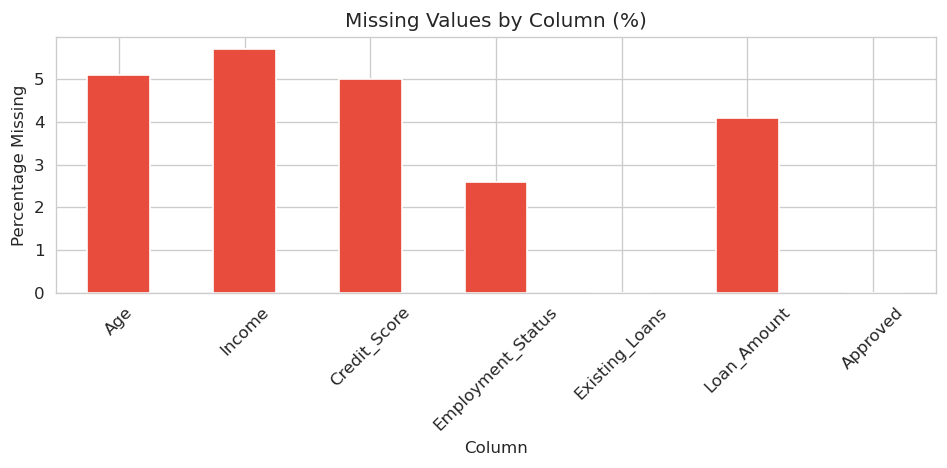

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind='bar', color='#e74c3c', ax=ax)
ax.set_title('Missing Values by Column (%)')
ax.set_ylabel('Percentage Missing')
ax.set_xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2b. Target Distribution

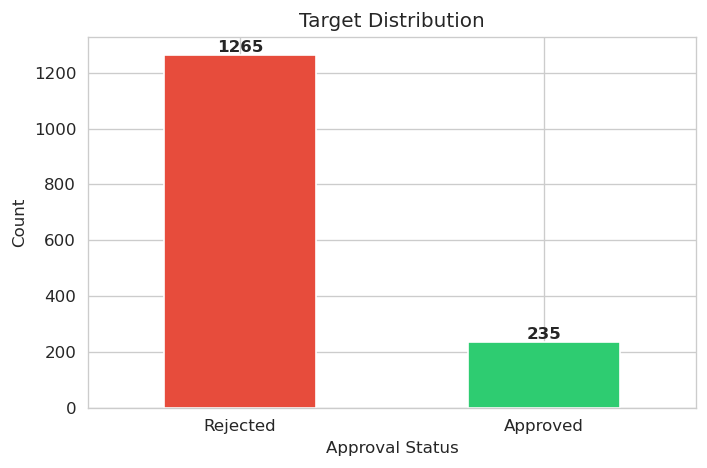

Approval rate: 15.67%


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Approved'].value_counts()
counts.index = ['Rejected', 'Approved']
counts.plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Approval Status')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(f"Approval rate: {df['Approved'].mean():.2%}")

### 2c. Numeric Feature Distributions

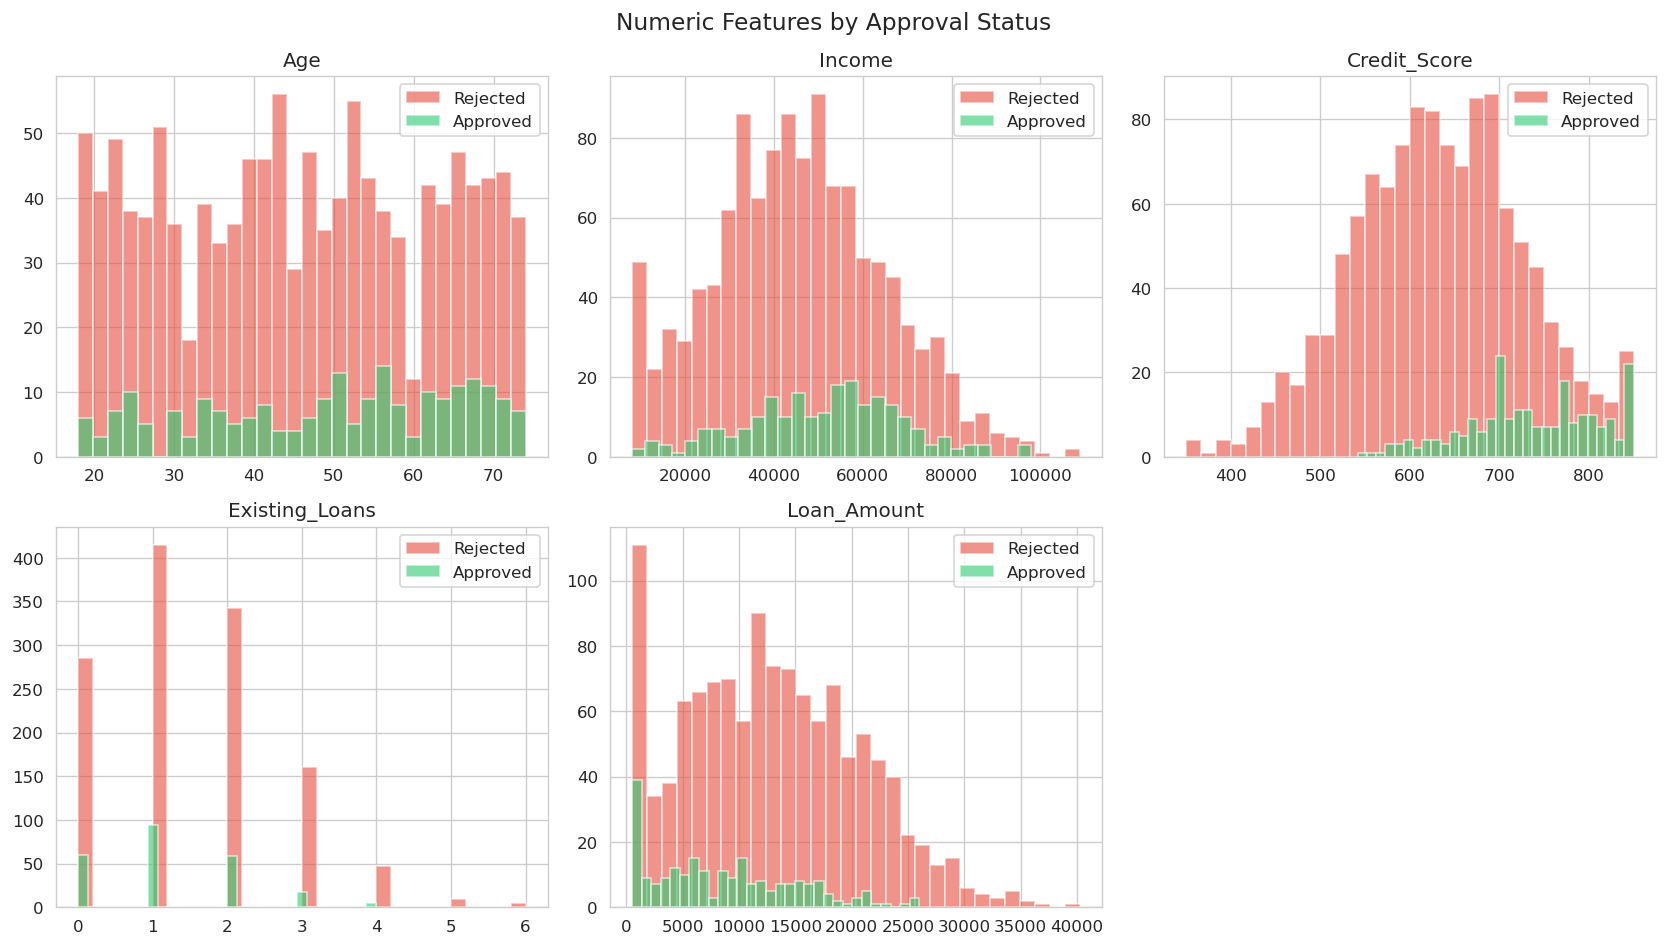

In [9]:
numeric_cols = ['Age', 'Income', 'Credit_Score', 'Existing_Loans', 'Loan_Amount']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
        subset = df[df['Approved'] == label][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label='Rejected' if label == 0 else 'Approved')
    axes[i].set_title(col)
    axes[i].legend()

axes[5].axis('off')
fig.suptitle('Numeric Features by Approval Status', fontsize=14)
plt.tight_layout()
plt.show()

### 2d. Employment Status vs Approval

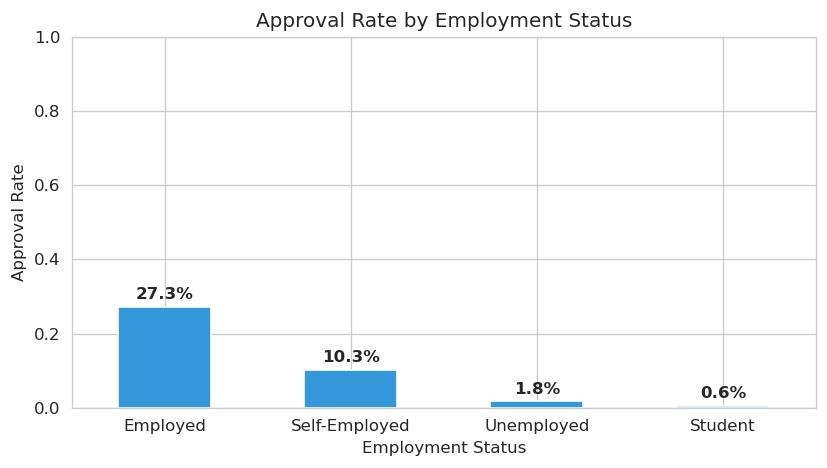

In [10]:
emp_approval = df.groupby('Employment_Status')['Approved'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
emp_approval.plot(kind='bar', color='#3498db', ax=ax)
ax.set_title('Approval Rate by Employment Status')
ax.set_ylabel('Approval Rate')
ax.set_xlabel('Employment Status')
ax.set_ylim(0, 1)
for i, v in enumerate(emp_approval.values):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2e. Correlation Heatmap

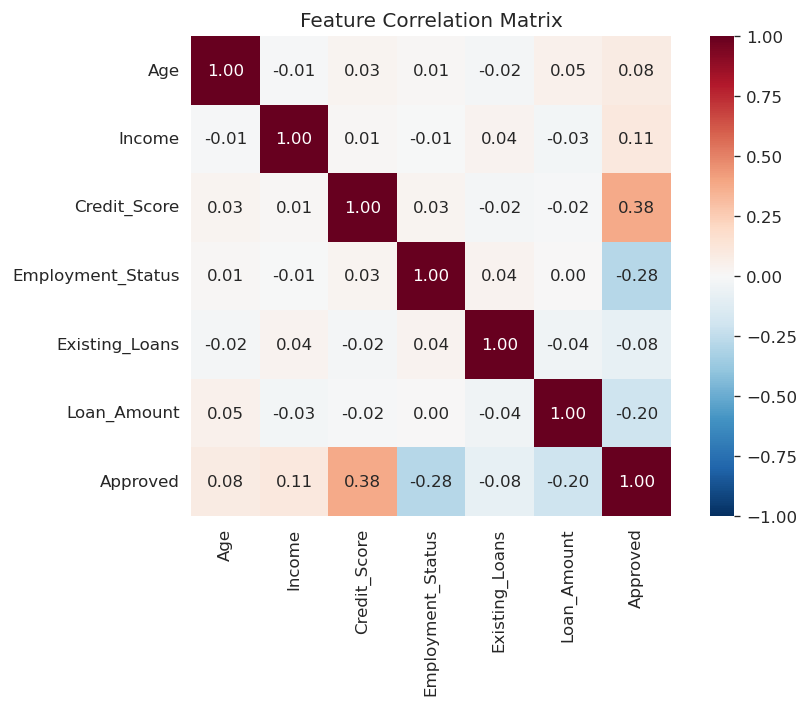

In [11]:
df_encoded = df.copy()
df_encoded['Employment_Status'] = df_encoded['Employment_Status'].astype('category').cat.codes

corr = df_encoded.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 2f. Box Plots — Key Features by Approval

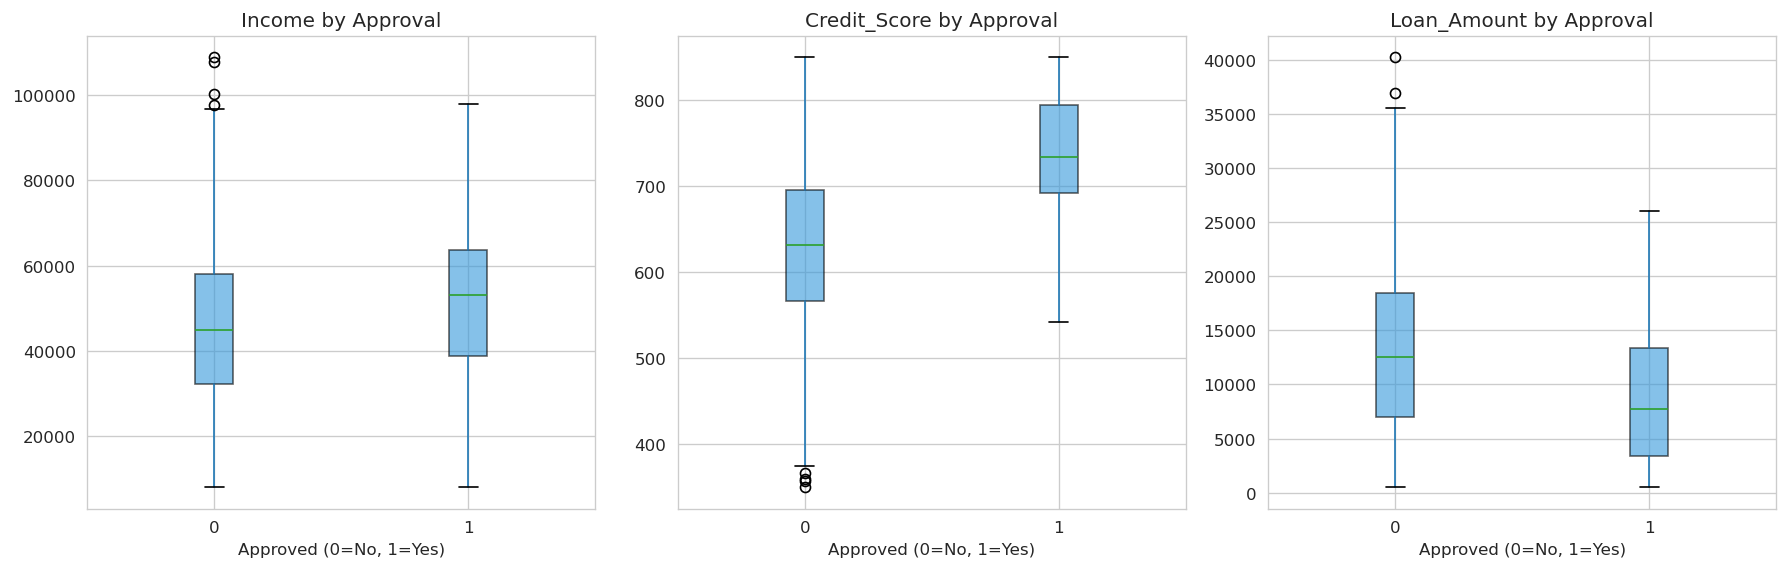

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['Income', 'Credit_Score', 'Loan_Amount']):
    df.boxplot(column=col, by='Approved', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    axes[i].set_title(f'{col} by Approval')
    axes[i].set_xlabel('Approved (0=No, 1=Yes)')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 3. Preprocessing Walkthrough

In [13]:
# Step-by-step preprocessing (same as src/preprocessing.py)

# 1. Handle missing values
df_clean = handle_missing_values(df)
print(f'\nMissing values after cleaning: {df_clean.isnull().sum().sum()}')

  Filled Age missing values with median=46.00
  Filled Income missing values with median=46136.63
  Filled Credit_Score missing values with median=651.00
  Filled Loan_Amount missing values with median=11822.83
  Filled Employment_Status missing values with mode=Employed

Missing values after cleaning: 0


In [14]:
# 2. Encode categoricals
df_encoded, encoders = encode_categoricals(df_clean)
print(f'\nEncoded columns: {list(encoders.keys())}')
for col, le in encoders.items():
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

  Encoded Employment_Status: {'Employed': np.int64(0), 'Self-Employed': np.int64(1), 'Student': np.int64(2), 'Unemployed': np.int64(3)}

Encoded columns: ['Employment_Status']
  Employment_Status: {'Employed': np.int64(0), 'Self-Employed': np.int64(1), 'Student': np.int64(2), 'Unemployed': np.int64(3)}


In [15]:
# 3. Train-test split
TARGET_COL = 'Approved'
X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1200, 6), Test: (300, 6)


In [16]:
# 4. Scale features
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)
print('\nScaled feature statistics (train):')
X_train_scaled.describe().round(2)


Scaled feature statistics (train):


,Age,Income,Credit_Score,Employment_Status,Existing_Loans,Loan_Amount
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.76,-2.07,-3.05,-0.85,-1.25,-1.54
25%,-0.82,-0.69,-0.65,-0.85,-0.37,-0.78
50%,-0.01,0.00,0.02,-0.85,-0.37,-0.05
75%,0.80,0.64,0.63,0.86,0.50,0.70
max,1.74,3.41,2.09,1.71,4.01,3.68


---
## 4. Model Training & Evaluation

In [17]:
# Train with GridSearchCV
best_model, grid = train_model(X_train_scaled, y_train)

MODEL TRAINING
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV f1: 0.5746


In [18]:
# GridSearchCV results summary
results = pd.DataFrame(grid.cv_results_)
results = results[['params', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score')
results.head(10)

,params,mean_test_score,rank_test_score
6,"{'C': 10, 'max_iter': 1000, 'penalty': 'l1', '...",0.574583,1
7,"{'C': 10, 'max_iter': 1000, 'penalty': 'l2', '...",0.574583,1
9,"{'C': 100, 'max_iter': 1000, 'penalty': 'l2', ...",0.574583,1
8,"{'C': 100, 'max_iter': 1000, 'penalty': 'l1', ...",0.574583,1
5,"{'C': 1, 'max_iter': 1000, 'penalty': 'l2', 's...",0.572566,5
4,"{'C': 1, 'max_iter': 1000, 'penalty': 'l1', 's...",0.570691,6
2,"{'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', ...",0.551347,7
3,"{'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', ...",0.550526,8
1,"{'C': 0.01, 'max_iter': 1000, 'penalty': 'l2',...",0.431082,9
0,"{'C': 0.01, 'max_iter': 1000, 'penalty': 'l1',...",0.000000,10


In [19]:
# Evaluate
metrics, y_pred = evaluate_model(best_model, X_test_scaled, y_test)

EVALUATION

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.94      0.97      0.96       253
    Approved       0.82      0.66      0.73        47

    accuracy                           0.92       300
   macro avg       0.88      0.82      0.84       300
weighted avg       0.92      0.92      0.92       300

Accuracy : 0.9233
Precision: 0.8158
Recall   : 0.6596
F1 Score : 0.7294


In [20]:
# Confusion Matrix
plot_confusion_matrix(y_test, y_pred, save_path='notebook_confusion_matrix.png')

Confusion matrix saved to notebook_confusion_matrix.png


In [21]:
# Feature Importance
plot_feature_importance(best_model, feature_names, save_path='notebook_feature_importance.png')

Feature importance plot saved to notebook_feature_importance.png


In [22]:
# ROC Curve
plot_roc_curve(best_model, X_test_scaled, y_test, save_path='notebook_roc_curve.png')

ROC curve saved to notebook_roc_curve.png


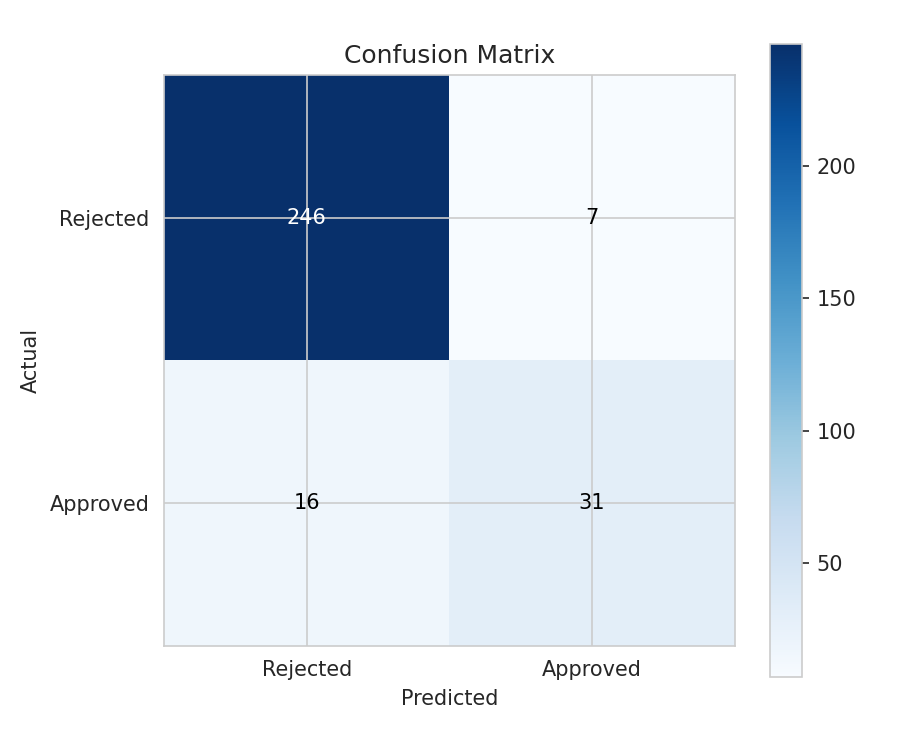

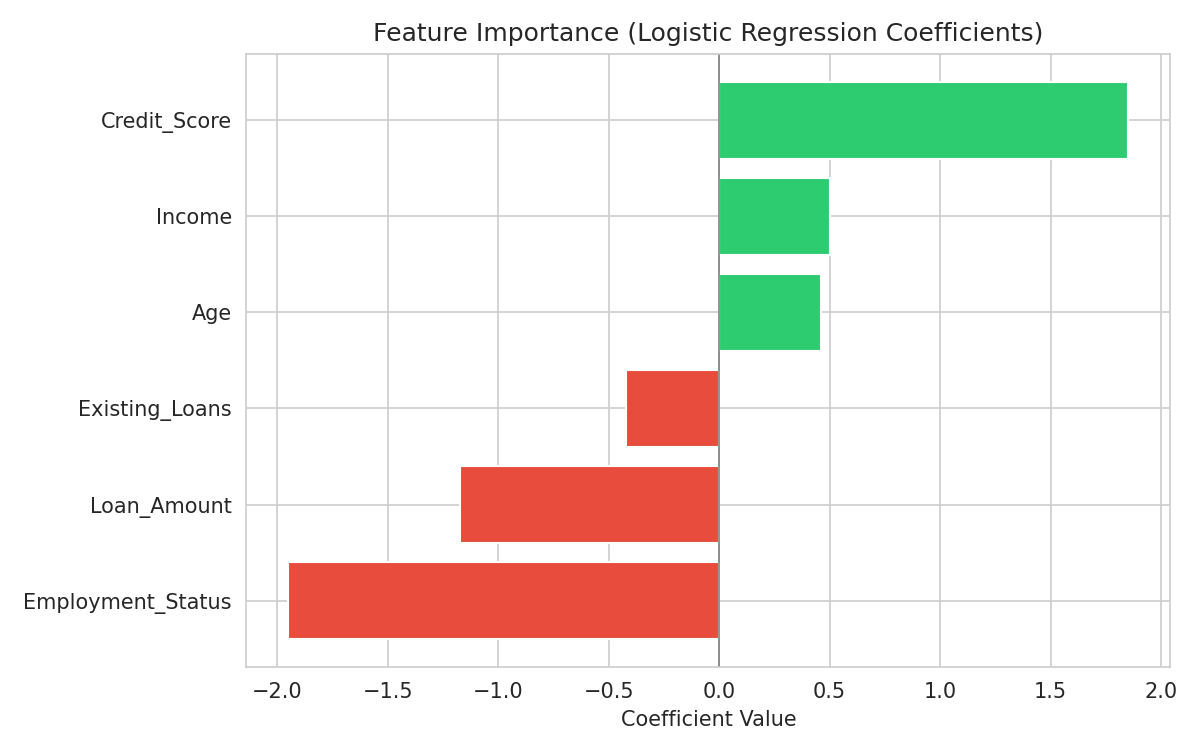

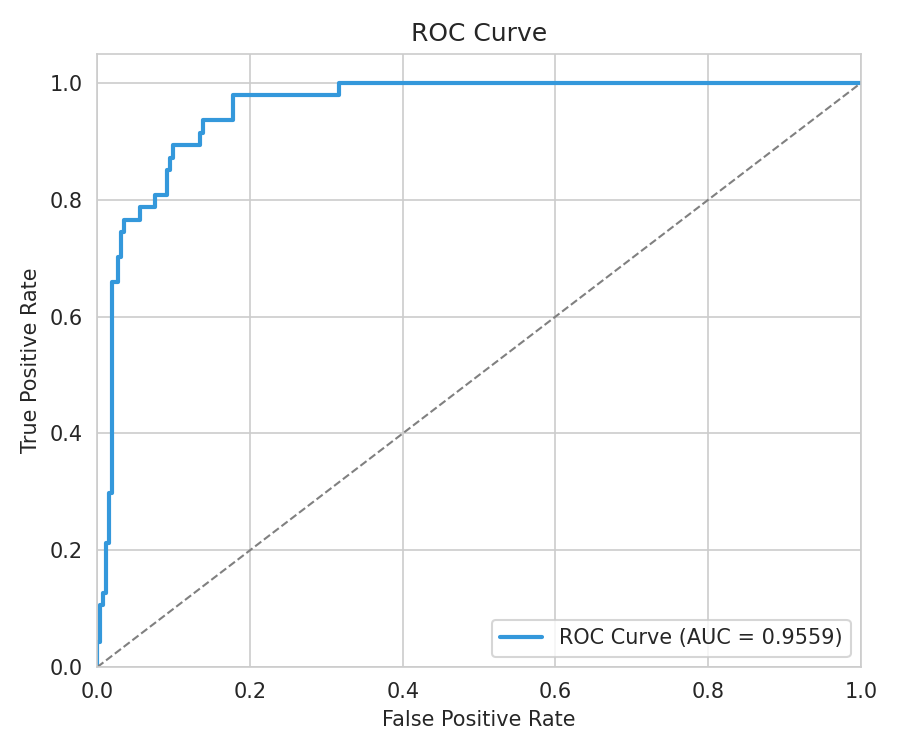

In [23]:
# Display all three plots inline
from IPython.display import Image, display

for img in ['notebook_confusion_matrix.png', 'notebook_feature_importance.png', 'notebook_roc_curve.png']:
    if os.path.exists(img):
        display(Image(filename=img))
        print()

---
## 5. Conclusions

- **Income** and **Credit Score** are the strongest positive predictors of approval.
- **Employment Status** plays a significant role — employed applicants have much higher approval rates.
- **Existing Loans** and **Loan Amount** negatively impact approval likelihood.
- The class is imbalanced (~16% approved), which explains the lower recall for the approved class.
- **Potential improvements**: Try SMOTE/oversampling, ensemble models (Random Forest, XGBoost), or threshold tuning to improve recall on the minority class.